*** Problem Statement ***

We have the Data of different restaurant and we want to predict how much revenue a restaurant will generate .

Type of Problem :

Revenue is a number(continuous value)

So this is a regression problem.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
df=pd.read_csv('/content/revenue_prediction.csv')


In [43]:
df

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...,...,...
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689


In [44]:
df.head(10)

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
5,106,Maggiano'sLittleItaly,Yes,Seafood,Noida,56,4.9,4517319
6,107,Cicis,Yes,Steak,Noida,58,5.0,5966635
7,108,LongJohnSilver's,Yes,Pizza,Mumbai,49,4.3,6491607
8,109,SaltgrassSteakHouse,Yes,Mexican,Mumbai,59,4.8,5152497
9,110,ChuckE.Cheese's,Yes,Steak,Pune,76,5.3,4544227


In [45]:
df.tail(10)

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
90,191,FarmerBoys,No,Family Style,Bengaluru,40,3.3,3426169
91,192,DonatosPizza,No,Mexican,Bengaluru,27,1.9,2083447
92,193,Shoney's,Yes,Varied Menu,Bengaluru,72,6.5,6782425
93,194,TacoBueno,No,Snack,Bengaluru,50,3.3,3410878
94,195,ClaimJumper,Yes,Bakery Cafe,Bengaluru,42,3.5,3753720
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689
99,200,Mimi'sBistro&Bakery,No,BBQ,Mumbai,50,4.4,4567678


ID: Unique ID for each restaurant.
Name:Name of the restaurant.
Franchise:Whether a restaurant is part of a franchise or not.
Category: Type of Restaurant.
City: place where the restaurant is located.
No_of_items:Number of items available in menu.
Order_placed:Total number of order placed(in Lakhs).
Revenue:Total income generated by the restaurant.




In [46]:
# EDA


In [47]:
df.shape

(100, 8)

In [48]:
df.describe()

,Id,No_Of_Item,Order_Placed,Revenue
count,100.000000,100.000000,100.000000,1.000000e+02
mean,150.500000,49.080000,4.086000,4.395161e+06
std,29.011492,22.370923,2.055101,2.659932e+06
min,101.000000,18.000000,1.000000,8.498700e+05
25%,125.750000,34.750000,2.750000,2.688328e+06
50%,150.500000,45.000000,3.650000,3.911401e+06
75%,175.250000,57.250000,5.100000,5.330084e+06
max,200.000000,126.000000,13.000000,1.969694e+07


In [49]:
df.isnull().sum()

,0
Id,0
Name,0
Franchise,0
Category,0
City,0
No_Of_Item,0
Order_Placed,0
Revenue,0


In [50]:
# Check for Null value
df.isnull().sum().sum()

np.int64(0)

In [51]:
# Check for Duplicate value
df.duplicated().sum()

np.int64(0)

In [52]:
# Delete the uncessary column
df.drop(['Id','Name'],axis=1,inplace=True)

In [53]:
df

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,Yes,Mexican,Bengaluru,55,5.5,5953753
1,No,Varied Menu,Gurugram,72,6.8,7223131
2,Yes,Chicken,Pune,25,1.9,2555379
3,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...
95,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,Yes,Sports Bar,Pune,25,2.1,2344689


In [54]:
# Convert Categorical Column into numerical
from sklearn.preprocessing import LabelEncoder


In [55]:
le=LabelEncoder()

In [56]:
for i in df.columns:
  if df[i].dtype=="object":
    df[i]=le.fit_transform(df[i])

In [57]:
df

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,1,12,0,55,5.5,5953753
1,0,19,1,72,6.8,7223131
2,1,5,4,25,1.9,2555379
3,1,11,2,18,2.5,2175511
4,1,13,3,48,4.2,4816715
...,...,...,...,...,...,...
95,0,11,0,19,1.1,1270499
96,1,19,0,75,6.3,6412623
97,1,19,1,77,6.2,6694797
98,1,17,4,25,2.1,2344689


In [58]:
# Split the Data into Independent and Dependent variable
x=df.iloc[:,:-1]
y=df['Revenue']

In [59]:
x

,Franchise,Category,City,No_Of_Item,Order_Placed
0,1,12,0,55,5.5
1,0,19,1,72,6.8
2,1,5,4,25,1.9
3,1,11,2,18,2.5
4,1,13,3,48,4.2
...,...,...,...,...,...
95,0,11,0,19,1.1
96,1,19,0,75,6.3
97,1,19,1,77,6.2
98,1,17,4,25,2.1


In [60]:
y

,Revenue
0,5953753
1,7223131
2,2555379
3,2175511
4,4816715
...,...
95,1270499
96,6412623
97,6694797
98,2344689


In [61]:
from sklearn.model_selection import train_test_split

In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

# Model Building


In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lr=LinearRegression()

In [65]:
# Train the Model
lr.fit(x_train,y_train)

LinearRegression()

In [66]:
# Test the model
y_pred=lr.predict(x_test)

In [67]:
y_pred

array([6666479.57324263, 5639644.54872309, 3805536.39463167,
       4193324.18078208, 4343130.14047885, 3771286.28284555,
       3975231.17369166, 3538465.19057696, 4008270.62952065,
       6564461.36756485, 5475587.89962776, 3049610.70004873,
       2810473.9006414 , 2279966.85189423, 3582880.67553956,
       4520150.55828419, 5132586.00030909, 1439624.56657968,
       1771028.10021913, 2139029.64016056])

In [68]:
# Evaluate the model
from sklearn.metrics import r2_score

In [69]:
r2_score(y_test,y_pred)

0.8639287715046499

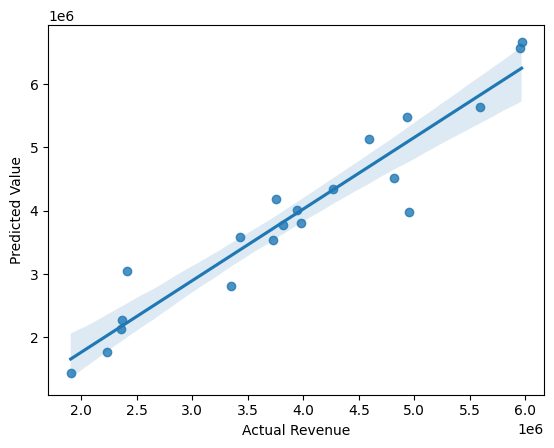

In [70]:
# Visualize the predictions
sns.regplot(x=y_test,y=y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Value')
plt.show()